This project walks through the **various stages of analysis** involved in tackling a **classification problem**, from exploratory data analysis (EDA) to model selection. The outcome of this analytical pipeline is a model that predicts whether a person will pay a loan back or not.

The Data set used here was obtained from the *Predicting Loan Payback* [Kaggle competition](https://www.kaggle.com/competitions/playground-series-s5e11/rules#7.-data-access-and-use). The data are used in accordance with the Apache 2.0 license and competition rules. The specific environment used for the entire project is available [here](https://github.com/znogbes/kaggle-predicting-loan-payback/blob/main/environment.yml).

**This page covers EDA and data preparation for modelling.** The packages used for this are shown below.

In [1]:
# set up
import pandas as pd
import kaggle
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick
from matplotlib.ticker import PercentFormatter

# Data import

The block below downloads data directly to a data directory using the Kaggle API. The data only needs downloading from Kaggle once, so the `try except` statement checks whether data files are present in the data directory already (e.g., when we do a re-run of the script).

Note that 2 files are downloaded from the API, but the only the `train.csv` file will be used in this project.

<details markdown="1">
<summary><b>Show code</b></summary>

In [ ]:
# upload data
try:
    # if already downloaded, just read csv
    data = pd.read_csv("data/train.csv")

except FileNotFoundError:
    # if downloading for the first time
    import os
    from kaggle.api.kaggle_api_extended import KaggleApi
    import zipfile

    # authenticate
    api = KaggleApi()
    api.authenticate()

    # download data
    # data directory
    data_dir = "./data/"
    # ensure directory exists
    os.makedirs(data_dir, exist_ok=True)

    api.competition_download_files(competition='playground-series-s5e11',
                                   path=data_dir)

    # unzip files
    with zipfile.ZipFile("data/playground-series-s5e11.zip", 'r') as zip_ref:
        zip_ref.extractall("data/")
    
    data = pd.read_csv("data/train.csv")

</details>

# Exploratory data analysis (EDA)

This particular data set was created synthetically, so we wouldn't expect common data quality issues such as missing values. You can validate that this is the case - by checking the number of non-null values (which is equal to the number of entries, or rows, in the data set). 

In [ ]:
# data exploration (train data)
data.columns.to_list()
data.info() # no missing values in any columns 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


## **What's the breakdown of the outcome variable?**

`loan_paid_back` has been coded as 0's (non-payers) and 1's (payers). Before we do any exploratory analysis on the predicting variables (or features), it's useful to know whether the outcome we are trying to predict is balanced. In this data set, the outcome is unbalanced: almost 80% of the sample paid their loan back.

In [ ]:
# payback outcome breakdown
df = pd.DataFrame({
    'n': data['loan_paid_back'].value_counts().map('{:,}'.format),
    'percentage': 100*data['loan_paid_back'].value_counts(normalize=True).round(3)
    })
df

# make pretty for markdown display
df.style.format(precision=1).relabel_index(['Payers', 'Non-payers'], axis=0)

,n,percentage
loan_paid_back,,
Payers,"474,494",79.9
Non-payers,"119,500",20.1


## **Numeric features**

Although synthetic, this data set has a mix of numeric and categorical variables, just like real-life data sets. We'll start exploring numeric features of the data by checking their distribution with the `describe()` method. Note that before we do that, we drop the `id` variable as it has no utility for analysis because it's a unique row identifier. Similarly, we exclude the outcome variable, as this step is concerned with features only.

In [ ]:
# permanently remove id col
data.drop('id', inplace=True, axis=1)

# exploratory data analysis - numeric variables
# drop dependent variable (since it's been coded as 1 and 0)
data.describe().drop('loan_paid_back', axis=1)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,48212.202976,0.120696,680.916009,15020.297629,12.356345
std,26711.942078,0.068573,55.424956,6926.530568,2.008959
min,6002.430000,0.011000,395.000000,500.090000,3.200000
25%,27934.400000,0.072000,646.000000,10279.620000,10.990000
50%,46557.680000,0.096000,682.000000,15000.220000,12.370000
75%,60981.320000,0.156000,719.000000,18858.580000,13.680000
max,393381.740000,0.627000,849.000000,48959.950000,20.990000


The table above already offers insights into the data. As expected from variables that describe financial information, we can tell, by looking at the standard deviations and range of values, that most of these variables have a **right or left skew**. 

However, presenting a table like this to non-technical stakeholders might be overwhelming, so I;d argue it's best to **visualise this information**, and compare the outcome groups (payers vs. non-payers) while we're at it. 

You can either use box plots or histograms to visualise the distribution of numeric variables. In my opinion, the choice of which to use might depend of which audience you'll be presenting to. I would go for box plots if presenting to a non-technical audience, but use histograms with technical audiences.

### **Box plots**

Below, I have:
- divided the data by outcome group
- selected numeric features
- looped through each feature
- graphed box plots using `matplotlib`

*Note:* I have made the bars horizontal and made the whiskers represent minimum and maximum values for the corresponding outcome group. I think those choices improve readability for non-technical stakeholders.

<details markdown="1">
<summary><b>Show code</b></summary>

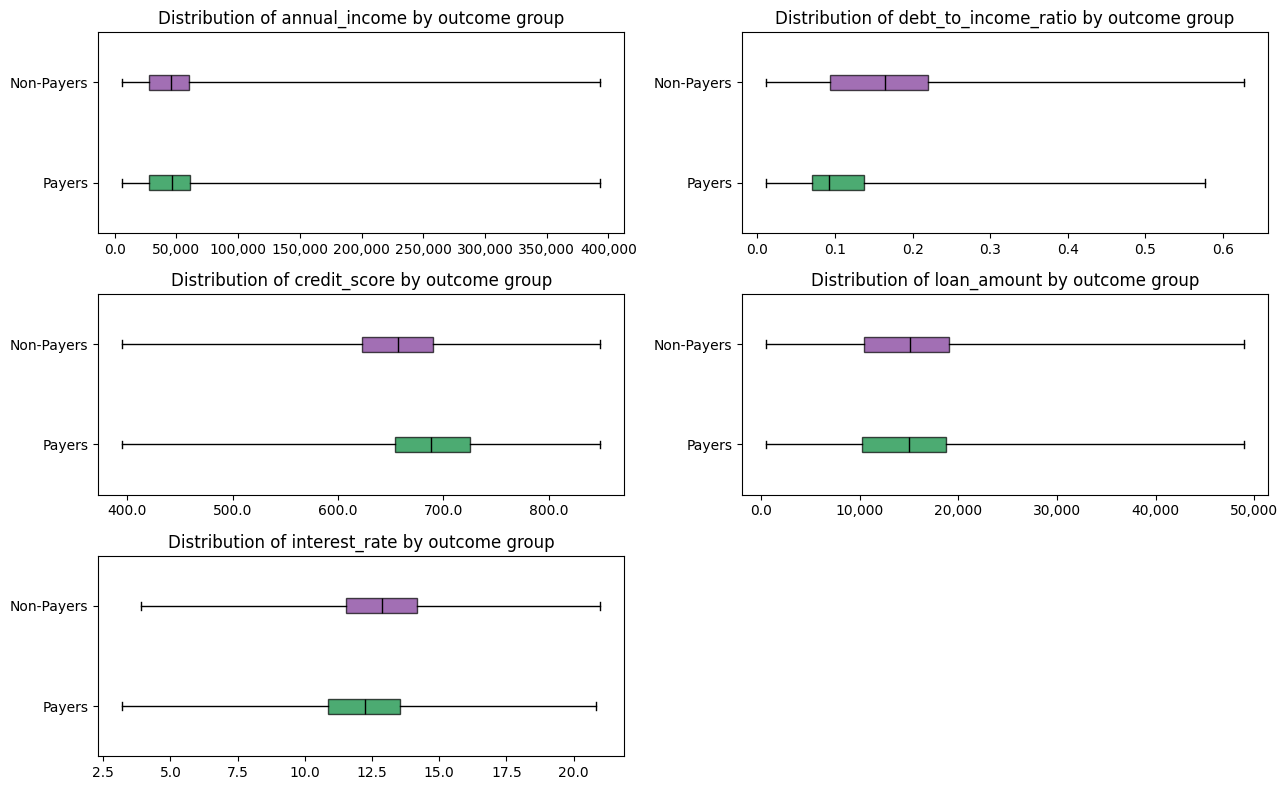

In [ ]:
# create df's by payback group 
filter = data['loan_paid_back'] == 1
data_payers = data[filter]
filter = data['loan_paid_back'] == 0
data_non_payers = data[filter]

# visualisation of numeric variables
# define cols to loop through in plot
numeric_cols = data_payers.select_dtypes(
    include=np.number).columns.drop('loan_paid_back')
# determine grid size
num_cols = len(numeric_cols)
ncols = 2
nrows = int(np.ceil(num_cols/2)) # in case of single row/col

# define plot objects
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 8))
axes = axes.flatten()

# make boxplots
for i, col in enumerate(numeric_cols):
    ax = axes[i]

    # create boxplot for col
    bp = ax.boxplot(
        [data_payers[col], data_non_payers[col]],
        labels=['Payers', 'Non-Payers'],
        # allow custom colours 
        patch_artist=True,
        # horizontal orientation of bars
        vert=False,
        # make whiskers represent min and max values
        whis = (0, 100)
        )
    
    colours = ['#008837', '#7b3294']
    for patch, colour in zip(bp['boxes'], colours):
        patch.set_facecolor(colour)
        patch.set_alpha(0.7)

    for median in bp['medians']:
        median.set(color='black')
    
    ax.set_title(f"Distribution of {col} by outcome group")
    ax.get_xaxis().set_major_formatter(
        # custom format for large/small scales
        mtick.FuncFormatter(lambda x, p: format(x, ',.0f') if x >=1000 else
        # use commas for large scales, 1 decimal for small scales 
                            format(x, '.1f'))
                            )
 
# hide unused subplots
for i in range(num_cols, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

</details>

### **Histograms**

I think these are a better fit for technical audiences, particularly if you're discussing skewness or considering transformations to the data. I have chosen not to fill the inside of the histogram bars - given the overlaps observed between the distributions of payers and non-payers. 

<details markdown="1">
<summary><b>Show code</b></summary>

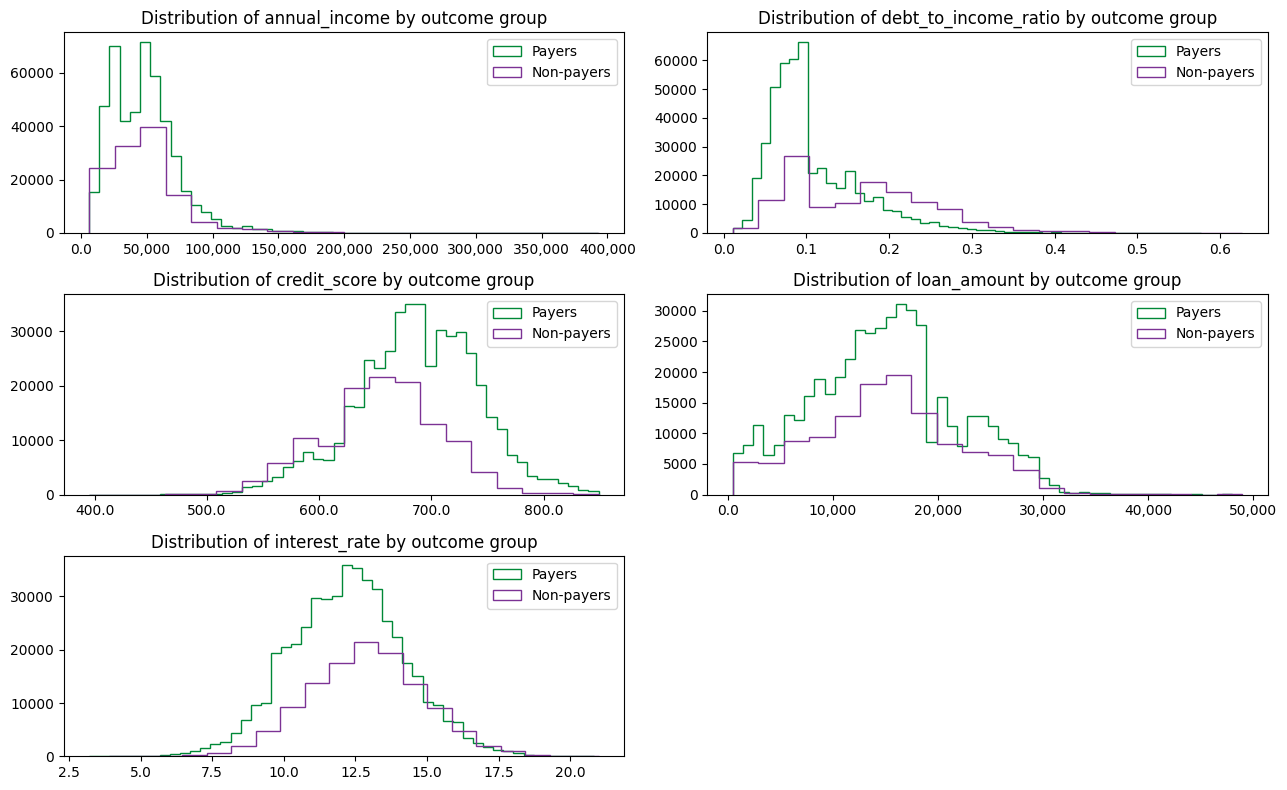

In [ ]:
# alternatively, these variables can also be visualised as histograms
fig, axes = plt.subplots(nrows,ncols, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]

    # create histograms for each group
    ax.hist(
        data_payers[col], bins=50,  
        color='#008837',
        label='Payers', 
        histtype = 'step'
        )
        
    ax.hist(
        data_non_payers[col], bins=20, 
        color='#7b3294',
        label='Non-payers', histtype = 'step'
        )
    
    ax.set_title(f"Distribution of {col} by outcome group")
    ax.legend()
    ax.get_xaxis().set_major_formatter(
        # custom format for large/small scales
        mtick.FuncFormatter(lambda x, p: format(x, ',.0f') if x >=1000 else
        # use commas for large scales, 1 decimal for small scales 
                            format(x, '.1f'))
                            )

#hide unused subplots
for i in range(num_cols, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

</details>

## Categorical features

You can explore categorical variables by generating breakdown tables for each outcome group and compare those breakdowns visually in a plot. Doing so can allow you to answer questions such as *is the non-payer group made up of more unemployed people than the payer group?* 

We can make a function to produce frequency tables (counts and percentages) and another one to graph the percentage *within* the outcome groups who fall in every category, making it easier to compare across variables.

<details markdown="1">
<summary><b>Show functions</b></summary>

In [ ]:
# visualisation of categorical variables

# recode outcome variable for displaying tables and plots
recode_dict = {1:'Payers', 0:'Non-Payers'}
data['outcome'] =  data['loan_paid_back'].map(recode_dict)

# generate frequency tables by outcome group
def generate_freq_table(data, col_name):
    # frequencies of categorical vol by outcome 
    count_table = pd.crosstab(data[col_name], data['outcome'])
    # reset index so categorical variable is not kept as index
    count_table = count_table.reset_index()
    # calculate percentages by outcome group
    percent_payers = (
        count_table['Payers']/count_table['Payers'].sum()*100).round(1)
    percent_non_payers = (
        count_table['Non-Payers']/count_table['Non-Payers'].sum()*100).round(1)
    count_table['perc_payers'] = percent_payers
    count_table['perc_non_payers'] = percent_non_payers
    # sort values by count of payers 
    frequency_table = count_table.sort_values(by='Payers', ascending=False)
    return frequency_table

# function to plot frequencies by group
def plot_categorical_cols(freq_table, col_name):
    # drop count columns, as the plot is for percentages
    freq_table_tidy = freq_table.drop(['Payers', 'Non-Payers'], axis=1)
    freq_table_tidy.plot(x = col_name, kind='barh', color=['#008837', '#7b3294'])
    # axis labels
    plt.xlabel('Percent')
    plt.gca().xaxis.set_major_formatter(
        # data already scalled to percent, 100
        PercentFormatter(100))
    plt.ylabel('')
    # show bars in desc order
    plt.gca().invert_yaxis()
    plt.title(f"Breakdown of outcome group by \n{col_name}")
    custom_labels = ['Payers', 'Non-Payers']
    plt.legend(loc='lower right', frameon = False, labels=custom_labels)
    plt.show()

</details>

We can then loop through every categorical variable and use both functions. You can see what the output looks like for `gender` and click on the arrow to see the results for the rest of the variables. 

<details markdown="1">
<summary><b>Show all categorical variables</b></summary>


Breakdown of outcome group by gender

outcome  gender  Non-Payers  Payers  perc_payers  perc_non_payers
0        Female       60712  245463         51.7             50.8
1          Male       58025  226066         47.6             48.6
2         Other         763    2965          0.6              0.6


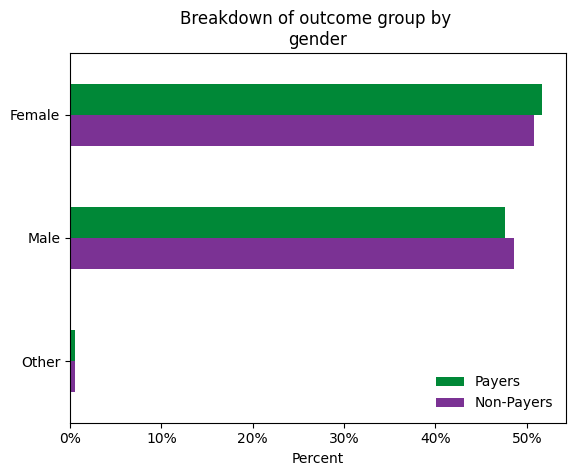


Breakdown of outcome group by marital_status

outcome marital_status  Non-Payers  Payers  perc_payers  perc_non_payers
2               Single       58094  230749         48.6             48.6
1              Married       55685  221554         46.7             46.6
0             Divorced        4334   16978          3.6              3.6
3              Widowed        1387    5213          1.1              1.2


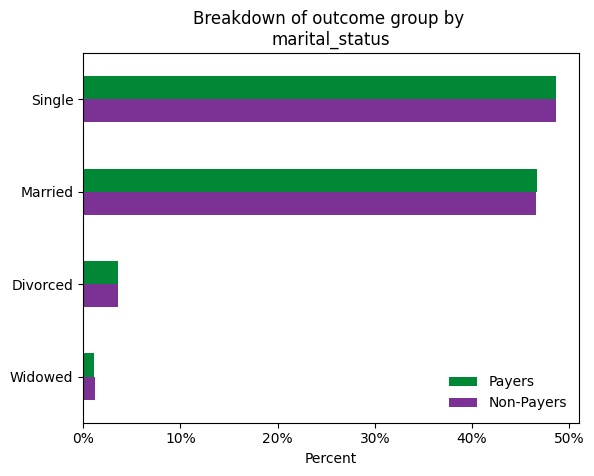


Breakdown of outcome group by education_level

outcome education_level  Non-Payers  Payers  perc_payers  perc_non_payers
0            Bachelor's       59027  220579         46.5             49.4
1           High School       34938  148654         31.3             29.2
2              Master's       18401   74696         15.7             15.4
3                 Other        5261   21416          4.5              4.4
4                   PhD        1873    9149          1.9              1.6


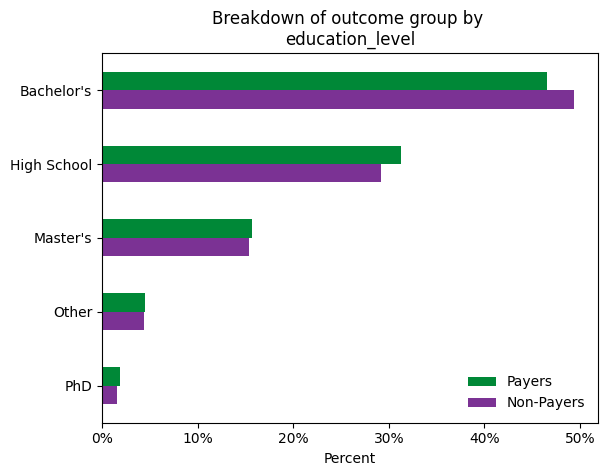


Breakdown of outcome group by employment_status

outcome employment_status  Non-Payers  Payers  perc_payers  perc_non_payers
0                Employed       47703  402942         84.9             39.9
2           Self-employed        5329   47151          9.9              4.5
1                 Retired          46   16407          3.5              0.0
4              Unemployed       57635    4850          1.0             48.2
3                 Student        8787    3144          0.7              7.4


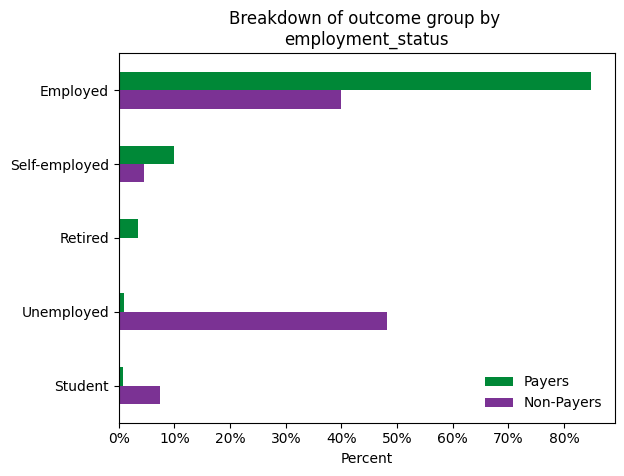


Breakdown of outcome group by loan_purpose

outcome        loan_purpose  Non-Payers  Payers  perc_payers  perc_non_payers
2        Debt consolidation       65942  258753         54.5             55.2
6                     Other       12623   51251         10.8             10.6
1                       Car       11585   46523          9.8              9.7
4                      Home        7799   36319          7.7              6.5
0                  Business        6598   28705          6.0              5.5
3                 Education        8169   28472          6.0              6.8
5                   Medical        5061   17745          3.7              4.2
7                  Vacation        1723    6726          1.4              1.4


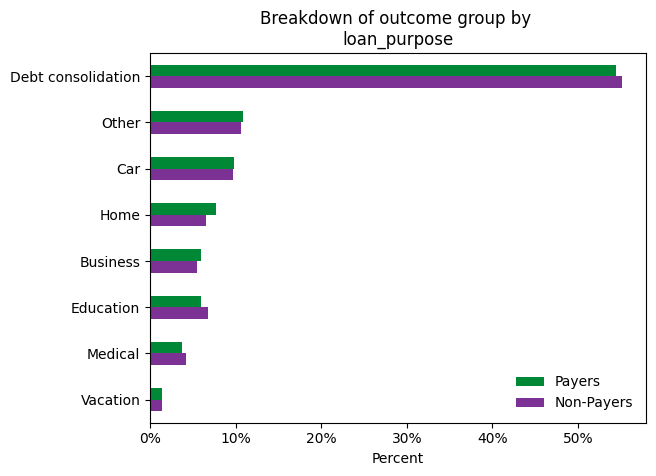


Breakdown of outcome group by grade_subgrade

outcome grade_subgrade  Non-Payers  Payers  perc_payers  perc_non_payers
12                  C3        9626   49069         10.3              8.1
13                  C4        8730   47227         10.0              7.3
11                  C2        8103   46340          9.8              6.8
10                  C1        7466   45897          9.7              6.2
14                  C5        8197   45120          9.5              6.9
15                  D1        9928   27101          5.7              8.3
17                  D3       11156   25538          5.4              9.3
18                  D4       10012   25085          5.3              8.4
16                  D2        9608   24824          5.2              8.0
19                  D5        9213   22888          4.8              7.7
6                   B2         949   14218          3.0              0.8
5                   B1        1200   13144          2.8              1.0
7   

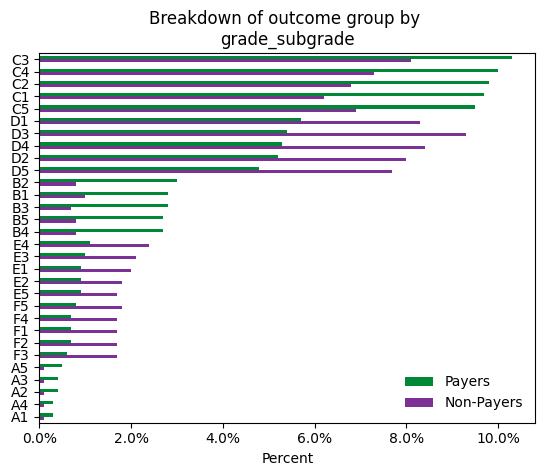

In [ ]:
# loop over to see freq tables and plots
categorical_cols = data.select_dtypes(include='object').drop(
    'outcome', axis=1)

for col in categorical_cols:
    print(f"\nBreakdown of outcome group by {col}\n")
    freq_table = generate_freq_table(data, col)
    print(freq_table)
    plot_categorical_cols(freq_table, col)

</details>

## Insights from EDA

The plots in the previous sections offer us an idea of which features might be strong predictors when we come to modelling. 

In the case of numeric features, we can see - by looking at the medians in the box plots - that **non-payers have higher ratios of debt-to-income** and **lower credit scores** than payers. This probably reflects high borrowing behaviour and past tendencies of late payments. Interestingly, annual income, loan amounts and interest rates seemed similar in both groups.  

In the categorical feature exploration, the most noticeable insight was the clear differences in employment status. About **85% of payers were employed** vs only 40% of non-payers. Almost half **(48.2%) of non-payers were unemployed** vs just 1% in the payer group. There also seemed to be differences between groups in the grade-subgrade variables. Specifically, there were higher proportions of payers in the B and C grades, but lower in the D and E grades. 

These insights will need to be confirmed by any modelling we do, but the idea of EDA is to get a lay of the land. For instance, the differences seen in grade-subgrade might fade or not be significant due to the many possible values for that variable.  

## Getting data ready for modelling (pre-processing)

Before we can move to modelling, we have to make sure that the data set is ready to be used for machine learning (ML). Many ML methods require encoding non-numerical features. First we need to know what type of encoding will be applied to the categorical columns, which will depend on how many levels there are in the category, and whether those levels represent any ordinal scales. The step below show us the possible values for every categorical feature in the data set.


In [ ]:
# drop temporary outcome col
data.drop('outcome', inplace=True, axis=1)

# select categorical col to encode
categorical_cols = data.select_dtypes(include='object')

# review all categories inform which type of coding to use
for col in categorical_cols:
    print(f"\nCategories in {col}:")
    categories = sorted(set(data[col]))
    print(categories)


Categories in gender:
['Female', 'Male', 'Other']

Categories in marital_status:
['Divorced', 'Married', 'Single', 'Widowed']

Categories in education_level:
["Bachelor's", 'High School', "Master's", 'Other', 'PhD']

Categories in employment_status:
['Employed', 'Retired', 'Self-employed', 'Student', 'Unemployed']

Categories in loan_purpose:
['Business', 'Car', 'Debt consolidation', 'Education', 'Home', 'Medical', 'Other', 'Vacation']

Categories in grade_subgrade:
['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5']


As we can see, all the categorical variables have multiple values, so this means they will need some form of encoding. The `grade_subgrade` column can be treated as an ordinal scale, so we create a dictionary with values from 0 to 29, to reflect the 30 different subgrades. Then we use that dictionary to turn the subgrades into a number.

In [ ]:
# create dictionary of categories and numeric values
grade_subgrades = sorted(set(data['grade_subgrade']))
grade_subgrades_order = np.arange(0,len(grade_subgrades)).tolist()
grade_subgrades_dict = dict(zip(grade_subgrades, grade_subgrades_order))

# use dictionary to execute ordinal recode in train data
data_encoded = data.copy()
data_encoded['grade_subgrade'] = data_encoded[
    'grade_subgrade'].replace(grade_subgrades_dict)

The remaining categorical features can be processed via one-hot encoding. This means that we sill split the original column into as many separate columns as there are unique values. For example, the recorded values for the `gender` variable are: female, male, and other. Hence, we will have 3 new columns: `gender_female`, `gender_male`, and `gender_other`. Each of these new variables will be coded TRUE or FALSE according to the original value in `gender`, so every row can only have one TRUE value across the 3 new derived variables. We repeat this process for every categorical variable. You can use the `get_dummies()` method inside a function to one-hot encode all eligible features in one go, as shown below.

In [ ]:
# the other categorical cols will undergo one-hot encoding  
one_hot_encoding_cols = categorical_cols.drop('grade_subgrade', axis=1)

# function to execute one-hot encoding
def one_hot_encode(data_ordinal_encoded, columns_to_encode):
    # df to save results form loop below
    data_one_hot_encoded = data_ordinal_encoded.copy()
    
    for col in columns_to_encode:
        # # identify variable to encode
        col_multi_categorical = data_ordinal_encoded[col]
        # use get_dummies method for one-hot encoding
        cols_coded = pd.get_dummies(col_multi_categorical, prefix=col)
        # join encoded data to initial data frame
        data_one_hot_encoded = pd.concat([data_one_hot_encoded, cols_coded], 
                                         axis=1)
        # drop multi categorical col, for we have new individual cols for every category
        data_one_hot_encoded.drop([col], axis=1, inplace=True)
    
    return data_one_hot_encoded

# deploy
data_encoded = one_hot_encode(data_encoded, one_hot_encoding_cols)

Finally, let's have a look at the new variables generated and save the ML-ready data locally so we can use in modelling scripts.

In [ ]:
print(data_encoded.columns.to_list())
# write data
data_encoded.to_csv('./data/data_processed.csv', index=False)

['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'grade_subgrade', 'loan_paid_back', 'gender_Female', 'gender_Male', 'gender_Other', 'marital_status_Divorced', 'marital_status_Married', 'marital_status_Single', 'marital_status_Widowed', "education_level_Bachelor's", 'education_level_High School', "education_level_Master's", 'education_level_Other', 'education_level_PhD', 'employment_status_Employed', 'employment_status_Retired', 'employment_status_Self-employed', 'employment_status_Student', 'employment_status_Unemployed', 'loan_purpose_Business', 'loan_purpose_Car', 'loan_purpose_Debt consolidation', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Medical', 'loan_purpose_Other', 'loan_purpose_Vacation']


**Next, I will compare different ML methods** and do a bit of model evaluation to propose an optimal model for predicting whether someone will pay a loan back.